# Mandatory Practical Work 01
Leandros Giagiozis / ... <br>
Pascal Kern / kernpas1@students.zhaw.ch

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Normalize, Compose
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt

import wandb

In [2]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cuda


## Loading Data

In [3]:
# 64x64 data
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform
)

### Normalization

leads to faster and more stable training. Only with training data.

In [4]:
loader = DataLoader(train_data, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)  # flatten H and W
    mean += images.mean(dim=2).sum(dim=0)
    std += images.std(dim=2).sum(dim=0)
    total_samples += batch_size

mean /= total_samples
std /= total_samples
print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4965, 0.4792, 0.3941])
Std:  tensor([0.2008, 0.1974, 0.2012])


### Augmented Data
Every epoch each image looks slightly different to the model, artificially expanding the dataset and forcing the model to focus on the animal's features rather than memorizing exact pixel positions, orientations, or lighting conditions.

In [5]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

transform_augmented = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomCrop(64, padding=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform
)

train_data_augmented = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_augmented
)

val_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/validate",
    transform=transform
)

In [6]:
print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print(train_data.classes)

Train samples: 24000
Val samples: 6000
['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


In [7]:
image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 64, 64])
Label: 0


In [8]:
print("Min pixel value:", image.min())
print("Max pixel value:", image.max())

Min pixel value: tensor(-2.4332)
Max pixel value: tensor(3.0112)


/tmp/ipykernel_171838/4286855250.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean_t = torch.tensor(mean).view(3, 1, 1)
/tmp/ipykernel_171838/4286855250.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_t = torch.tensor(std).view(3, 1, 1)


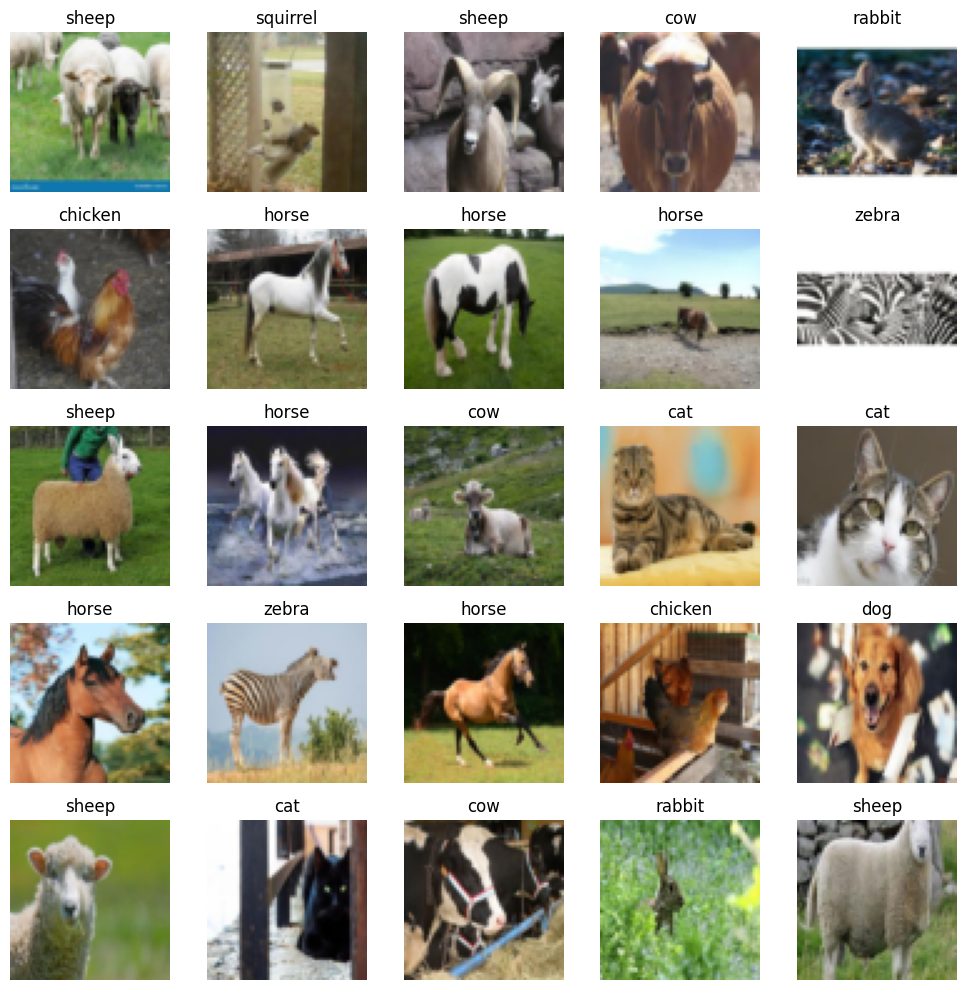

In [9]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

loader = DataLoader(train_data, batch_size=25, shuffle=True)
images, labels = next(iter(loader))

# denormalize
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)
images_denorm = images * std_t + mean_t
images_denorm = images_denorm.clamp(0, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i in range(25):
    img = images_denorm[i].permute(1, 2, 0)

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(train_data.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Models

To Evaluate the change that depth has on the Models we try to keep all the parameters the same, only with the number of Layers changing.
This means, that the amount of filters will stay the same, even in deeper Layers.

(This idea was discarded because no significant pattern could be identified in the differences between the models)

Idea: Each new layer essentially performs a similar transformation on the same features of the last Layer, resulting in redundant computations rather than richer abstractions. Increased depth must be paired with growing filter counts, allowing each layer to build progressively more abstract and diverse feature representations.

This is why we went with...

### Shallow Model

In [ ]:
class shallowModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(shallowModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [ ]:
# summary

model = shallowModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
 AdaptiveAvgPool2d-4             [-1, 16, 1, 1]               0
           Flatten-5                   [-1, 16]               0
            Linear-6                  [-1, 128]           2,176
              ReLU-7                  [-1, 128]               0
            Linear-8                   [-1, 10]           1,290
Total params: 3,914
Trainable params: 3,914
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 1.13
Params size (MB): 0.01
Estimated Total Size (MB): 1.19
----------------------------------------------------------------


### Medium Model

In [ ]:
class mediumModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(mediumModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*2, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [ ]:
# summary

model = mediumModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
           Flatten-8                   [-1, 32]               0
            Linear-9                  [-1, 128]           4,224
             ReLU-10                  [-1, 128]               0
           Linear-11                   [-1, 10]           1,290
Total params: 10,602
Trainable params: 10,602
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/ba

### Deep Model

In [ ]:
class deepModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(deepModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1), # 64, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 64, 8, 8

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*4, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [ ]:
model = deepModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
AdaptiveAvgPool2d-10             [-1, 64, 1, 1]               0
          Flatten-11                   [-1, 64]               0
           Linear-12                  [-1, 128]           8,320
             ReLU-13                  [-1, 128]               0
           Linear-14                   

### Deep Model2

In [6]:
class deepModel2(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(deepModel2, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1), # 64, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 64, 8, 8

            # Layer 4
            torch.nn.Conv2d(filter*4, filter*8, kernel_size=3, padding=1), # 128, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 128, 8, 8

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*8, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [ ]:
model = deepModel2().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
           Conv2d-10            [-1, 128, 8, 8]          73,856
             ReLU-11            [-1, 128, 8, 8]               0
        MaxPool2d-12            [-1, 128, 4, 4]               0
AdaptiveAvgPool2d-13            [-1, 128, 1, 1]               0
          Flatten-14                  [

## Training Loop

In [4]:
def train_eval(model, optimizer, nepochs, batch_size, training_data, validation_data, device, log_wandb = False, patience=10, min_delta=0.0):
    """
    Performs the training of a model with given learning rate (lr),
    number of epochs (nepochs), batchsize (batch_size) and training and validation data.
    Suitable data loaders are instantiated for the training and validation datasets.
    Keep book about cost and accuracy (per epoch) for both training and validation set.
    """
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    model = model.to(device)
    cost_ce = torch.nn.CrossEntropyLoss().to(device)

    train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False)

    # early stopping
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(nepochs):
        model.train()
        size = len(train_loader.dataset)
        nbatches = len(train_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(train_loader):
            X,Y = X.to(device),Y.to(device)
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            # gradient, parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(val_loader.dataset)
        nbatches_test = len(val_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in val_loader:
                X,Y = X.to(device),Y.to(device)
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))

        if log_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": cost,
                "train_acc": acc,
                "val_loss": cost_test,
                "val_acc": acc_test
            })

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

        # Early Stopping
        if cost_test < best_val_loss - min_delta:
            best_val_loss = cost_test
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

## Training

In [ ]:
models = {
    "shallow": (shallowModel, 1),
    "medium": (mediumModel, 2),
    "deep": (deepModel, 3),
    "deep2": (deepModel, 4)
}

for name, (ModelClass, n_layers) in models.items():
    wandb.init(
        project="PW01",
        name=name + "_width",
        config={
            "lr": 0.05,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 60,
            "filters": 16,
            "units": 128,
            "Model": name,
            "Layers": n_layers
        }
    )

    config = wandb.config

    model = ModelClass()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=config["lr"], momentum=config["momentum"])
    train_eval(model, optimizer, config["epochs"], config["batch_size"], train_data, val_data, device, log_wandb = True, patience=40)

    wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.303166, 0.099792, 2.293245, 0.116000
Epoch 1: 2.227513, 0.164625, 2.125191, 0.225167
Epoch 2: 2.090762, 0.230917, 2.038027, 0.257833
Epoch 3: 1.956585, 0.297167, 1.877508, 0.317333
Epoch 4: 1.806879, 0.359500, 1.724192, 0.391833
Epoch 5: 1.671393, 0.413500, 1.695056, 0.406667
Epoch 6: 1.535927, 0.462208, 1.489803, 0.473833
Epoch 7: 1.441549, 0.497417, 1.602831, 0.444833
Epoch 8: 1.365835, 0.523667, 1.349972, 0.535167
Epoch 9: 1.291494, 0.548583, 1.333172, 0.533833
Epoch 10: 1.244119, 0.566792, 1.267922, 0.557833
Epoch 11: 1.167075, 0.591458, 1.267390, 0.553667
Epoch 12: 1.130007, 0.602958, 1.302665, 0.553333
Epoch 13: 1.080516, 0.625125, 1.223759, 0.576000
Epoch 14: 1.037566, 0.640417, 1.272959, 0.578000
Epoch 15: 0.987177, 0.654333, 1.201548, 0.590000
Epoch 16: 0.945607, 0.672792, 1.240424, 0.585667
Epoch 17: 0.904409, 0.684667, 1.252785, 0.589167
Epoch 18: 0.882858, 0.695000, 1.350719, 0.565667
Epoch 19: 0.858067, 0.701917, 1.306240, 0.582667
Epoch 20: 0.826405, 0.715083, 

KeyboardInterrupt: 

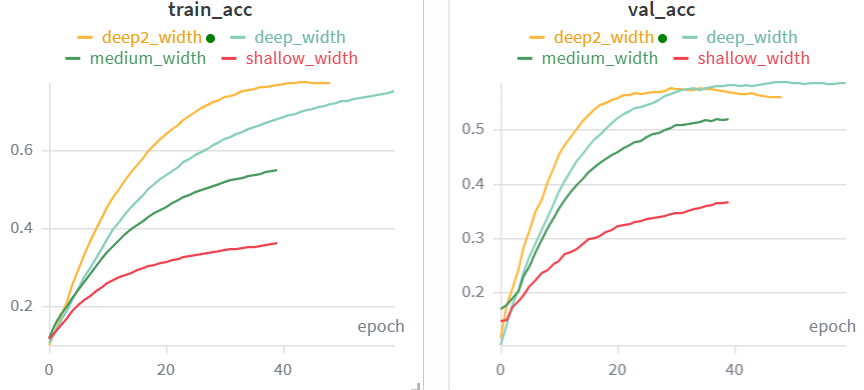

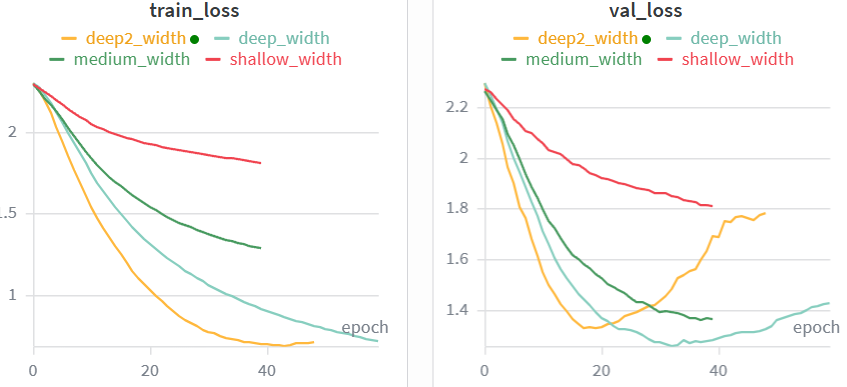

## a) Benefit of Depth
The potential of the models increases with depth. Multiple layers allow the model to work on different levels of abstraction and learn hierarchical features.

In the first layer the model might recognizes features like edges, corners, and color gradients. In the second layer the model might combine them into more structured patterns and in the third layer the model might begin to detect parts like eyes, ears, snouts, and limbs.

This is probably why the deep model performed better than the shallow one, since a single layer can only ever see raw edges, it has no mechanism to combine them into meaningful concepts. Each additional layer gives the model one more level of abstraction to work with.

That beeing said, we also see underfitting in the shallow model, a good fit in the medium one, the start of overfitting in the deep one and clear overfitting in the deep2 one. We will get back to that in Part c).

### Decision:
For further Exercises like Hyperparametertuning we use the deep Model since it is the most promessing and we didnt see an improvement with adding another layer in the deep2 Model.

## c) Show models that overfit and underfit and explain the reasons for that

Looking at our previously created Models below, we see underfitting with the shallow model. As mentioned in a) we assume the reason for unterfitting is the lack of model complexity and depth. We can see that the model even has trouble learning the training data. With just one single layer it can only see raw edges, it has no mechanism to combine them into meaningful concepts.

Underfitting can be cause by the following:
- Model too simple
- Training stopped too early (not enough epochs)
- Too strong regularisation
- Poor optimisation (e.g too low learningrate)

An overfitting model on the other hand is deep2. This becomes especially apparent when looking at the val_loss, which decreases but then starts rising after 20 epochs. Also the training accuracy lays at around 70% while the validation accuracy lays around 55% and is decreasing. A clear sign of overfitting.
Resons for this will be the model complexity in regards to the dataset size, aswell as not having regularization and training for too many epochs.

Overfitting can be caused by the following:
- Not enough training data (the model memorises instead of generalising)
- Model capacity too high  
- Training for too many epochs
- Too weak regularisation

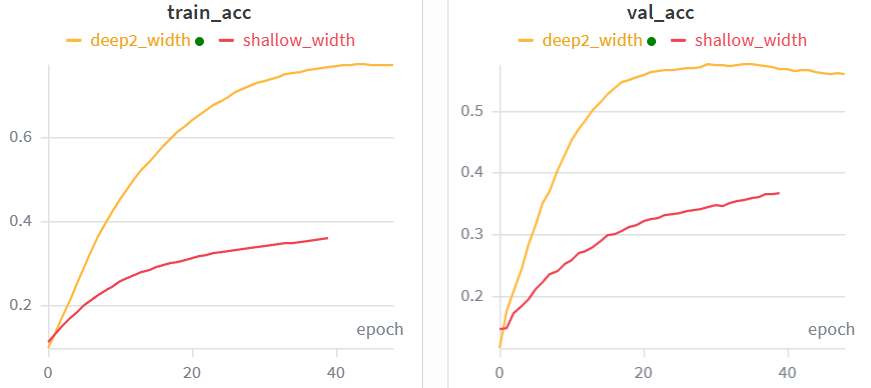

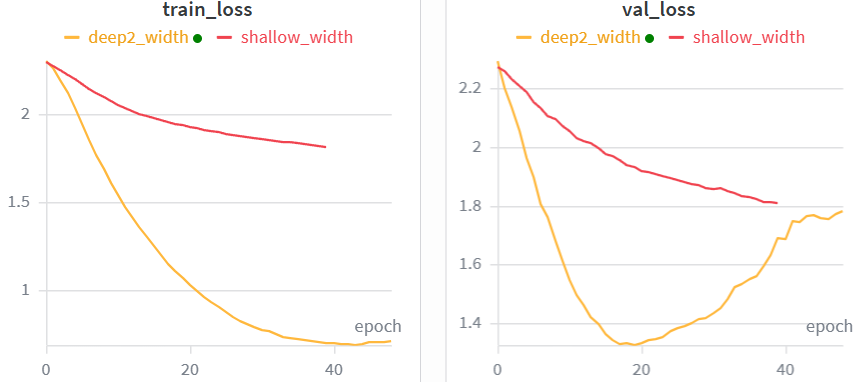

## c) Regularization

For this we take our most promising model (deep) which is also starting to overfit, and apply different regularization techniques to combat this. Namely Dropout, L2 regularization (weight decay), data augmentation and early stopping.

In [13]:
class deepModel_drop(torch.nn.Module):

    def __init__(self, units=128, filter=16, n_classes=10, dropout_conv=0.2, dropout_fc=0.5):
        super(deepModel_drop, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Flatten and Dense
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*4, units),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_fc),

            # Output
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)

In [13]:
model = deepModel_drop().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
         Dropout2d-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 32, 32, 32]           4,640
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
         Dropout2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
             ReLU-10           [-1, 64, 16, 16]               0
        MaxPool2d-11             [-1, 64, 8, 8]               0
        Dropout2d-12             [-1, 64, 8, 8]               0
AdaptiveAvgPool2d-13             [-1, 64, 1, 1]               0
          Flatten-14                   

In [ ]:
models = {
    "Data augment":  (deepModel,      train_data_augmented),
    "Drop":          (deepModel_drop, train_data),
    "L2":            (deepModel,      train_data),
    "Data augment, Drop and L2":   (deepModel_drop, train_data_augmented),
}

for name, (ModelClass, t_data) in models.items():

    weight_decay = 1e-4 if "L2" in name else 0.0

    wandb.init(
        project="PW01",
        name=name + " + early_stop",
        config={
            "lr": 0.02,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 100,
            "units": 128,
            "filters": 16,
            "dropout_conv": 0.1,
            "dropout_fc": 0.3,
            "weight_decay": weight_decay,
            "patience": 5
        }
    )

    config = wandb.config

    if "Drop" in name:
        model = ModelClass(units=config["units"],
                          filter=config["filters"],
                          dropout_conv=config["dropout_conv"],
                          dropout_fc=config["dropout_fc"])
    else:
        model = ModelClass(units=config["units"],
                          filter=config["filters"])

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=config["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               t_data, val_data, device, patience=config["patience"],
               log_wandb=True, min_delta=0.0)

    wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▂▄▆▇▇█▆▁▁▁
train_loss,▇▆▄▂▂▁▃███
val_acc,▄▅▇▇▇█▁▁▁▁
val_loss,▆▅▃▂▂▁████
epoch,9
train_acc,0.10133
train_loss,2.30447
val_acc,0.1
val_loss,2.30496


Epoch 0: 2.288004, 0.125208, 2.236053, 0.172833
Epoch 1: 2.192432, 0.197625, 2.089518, 0.248167
Epoch 2: 2.049555, 0.264208, 1.915058, 0.319167
Epoch 3: 1.987243, 0.282292, 1.872561, 0.337167
Epoch 4: 1.882633, 0.325167, 1.767644, 0.377167
Epoch 5: 1.830761, 0.345417, 1.745346, 0.390000
Epoch 6: 1.801079, 0.360500, 1.689033, 0.414167
Epoch 7: 1.757147, 0.375458, 1.631956, 0.427500
Epoch 8: 1.724232, 0.391708, 1.610271, 0.427333
Epoch 9: 1.684039, 0.409500, 1.547581, 0.451833
Epoch 10: 1.650629, 0.417875, 1.519329, 0.465333
Epoch 11: 1.622471, 0.428375, 1.472205, 0.489167
Epoch 12: 1.601469, 0.434958, 1.433285, 0.489333
Epoch 13: 1.564499, 0.448583, 1.438556, 0.493333
Epoch 14: 1.543979, 0.456458, 1.402264, 0.508333
Epoch 15: 1.526553, 0.465542, 1.401613, 0.499000
Epoch 16: 1.498134, 0.472083, 1.350832, 0.528333
Epoch 17: 1.486945, 0.478458, 1.316101, 0.540667
Epoch 18: 1.459422, 0.489042, 1.327482, 0.533667
Epoch 19: 1.446916, 0.493167, 1.304361, 0.544500
Epoch 20: 1.438235, 0.497917, 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
val_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,43
train_acc,0.56363
train_loss,1.24393
val_acc,0.609
val_loss,1.13428


Epoch 0: 2.264806, 0.142917, 2.158190, 0.234167
Epoch 1: 2.051282, 0.251958, 1.930309, 0.306333
Epoch 2: 1.891762, 0.317042, 1.820314, 0.339667
Epoch 3: 1.765016, 0.366458, 1.692664, 0.386333
Epoch 4: 1.659522, 0.409500, 1.613098, 0.421167
Epoch 5: 1.568437, 0.446542, 1.514710, 0.455500
Epoch 6: 1.497799, 0.470625, 1.450836, 0.484833
Epoch 7: 1.445958, 0.488958, 1.375878, 0.512167
Epoch 8: 1.372843, 0.517458, 1.445261, 0.482000
Epoch 9: 1.326644, 0.533792, 1.344113, 0.519833
Epoch 10: 1.289016, 0.548417, 1.296322, 0.540167
Epoch 11: 1.237415, 0.565250, 1.269043, 0.550333
Epoch 12: 1.208823, 0.574625, 1.242017, 0.561667
Epoch 13: 1.168377, 0.591125, 1.194887, 0.579667
Epoch 14: 1.149700, 0.593500, 1.214024, 0.570167
Epoch 15: 1.106157, 0.614958, 1.182365, 0.584333
Epoch 16: 1.073394, 0.625875, 1.146614, 0.595167
Epoch 17: 1.057515, 0.629667, 1.201672, 0.593000
Epoch 18: 1.044778, 0.634375, 1.128540, 0.610000
Epoch 19: 1.015141, 0.643208, 1.206316, 0.587833
Epoch 20: 0.980677, 0.657500, 

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▂▃▄▄▅▆▆▆▆▇▇▇▇▇███████████
val_loss,█▆▆▅▄▄▃▃▃▂▂▂▂▁▂▁▁▂▁▂▁▁▁▁▁▁
epoch,25
train_acc,0.68471
train_loss,0.902
val_acc,0.6065
val_loss,1.16136


Epoch 0: 2.278476, 0.134542, 2.212850, 0.180167
Epoch 1: 2.199401, 0.196042, 2.118311, 0.239167
Epoch 2: 2.106172, 0.233333, 2.000758, 0.287667
Epoch 3: 2.020235, 0.267875, 1.945421, 0.303333
Epoch 4: 1.937164, 0.301125, 1.803273, 0.358667
Epoch 5: 1.872075, 0.326875, 1.767896, 0.370833
Epoch 6: 1.834200, 0.343583, 1.719307, 0.398000
Epoch 7: 1.799731, 0.359125, 1.698196, 0.395167
Epoch 8: 1.767834, 0.368042, 1.662662, 0.417500
Epoch 9: 1.735922, 0.380292, 1.604630, 0.435833
Epoch 10: 1.702452, 0.397958, 1.560896, 0.460500
Epoch 11: 1.681097, 0.404875, 1.537527, 0.467500
Epoch 12: 1.655167, 0.412000, 1.553669, 0.457833
Epoch 13: 1.627947, 0.429250, 1.478427, 0.486667
Epoch 14: 1.601873, 0.434333, 1.476264, 0.484167
Epoch 15: 1.590141, 0.440625, 1.410963, 0.508000
Epoch 16: 1.566956, 0.447667, 1.392370, 0.516667
Epoch 17: 1.546151, 0.457083, 1.412366, 0.507167
Epoch 18: 1.534054, 0.461500, 1.371538, 0.521667
Epoch 19: 1.520579, 0.464000, 1.343863, 0.535833
Epoch 20: 1.512665, 0.469958, 

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▂▃▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▄▅▄▅▅▆▅▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇███████████
val_loss,█▇▇▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,52
train_acc,0.54212
train_loss,1.31818
val_acc,0.6035
val_loss,1.13563


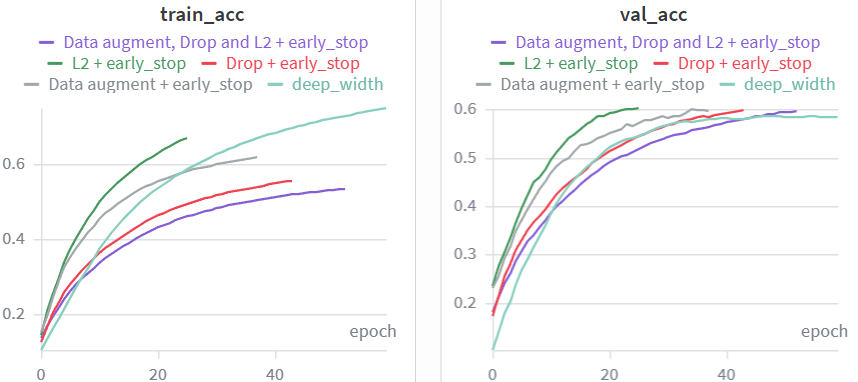

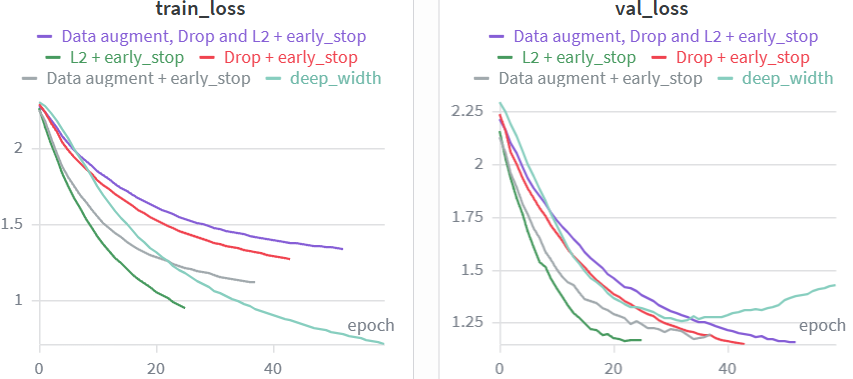

In the above graphs we can some interesting things. First of all we can say that all of the Regularization techniques did what they were supposed to, keep our model **deep_width** from overfitting, which is clearly visible with the training and validation loss. Also it lead to some performance improvements which is clearly visible in val_loss.

**Early Stopping** is our favourit, which we applied to all the trainings. It allows us to reduce the risk of underfitting by enabiling us to set a high epoch without the risk of overfitting and at the same time reducing time by cutting out unnessecary epochs (If val_loss doesnt improve for 5 epochs training is aborded (This was a bit an aggressive value, later increased it to 10)).

**Dropout** introduces noise during training by randomly deactivating neurons, forcing the network to learn more robust features. This is also why validation accuracy is higher than training accuracy in our runs.

**L2** regularization penalizes large weights, which prevents the model from relying too heavily on any single feature. We might have set it too low since the gap between training and validation accuracy is still rather big with 7%, indicating the model is still slightly overfitting.

**Data augmentation** expands the training set by applying changes (flips, crops, rotations, etc.) to the existing samples. It performed well, but we learned to be careful with the values and early stopping, since validation loss can fluctuate at the beginning because the augmented training images might differ substantially from the validation data,potentially triggering early stopping, before the model has had a chance to improve.

**All the above together** appears to be overly agressive and over-regularize, since the training took the most epochs without any significant improvement in validation accuracy over the others.






## b) Hyperparameter tuning


In [ ]:
run_configs = [
    {"name": "Run10_filter64_lr002_aug_L2",     "lr": 0.02,  "filters": 128, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 1e-4},
    {"name": "Run1_filter32",                   "lr": 0.02,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3, "augmented": False, "weight_decay": 0},
    {"name": "Run5_filter32_lr001_aug",         "lr": 0.01,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run2_filter64_lr002_aug",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run6_filter32_lr002_aug",         "lr": 0.02,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3, "augmented": True, "weight_decay": 0},  
    {"name": "Run8_filter128_lr002_aug",        "lr": 0.02,  "filters": 128, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run9_filter64_lr001_aug",         "lr": 0.01,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True}, "weight_decay": 0,
]

for cfg in run_configs:
    train_data_used = train_data_augmented if cfg["augmented"] else train_data

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pascal/.netrc.
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.253113, 0.155875, 2.185688, 0.194833
Epoch 1: 2.080806, 0.247708, 1.977906, 0.320167
Epoch 2: 1.950094, 0.291625, 1.847247, 0.350833
Epoch 3: 1.837303, 0.338458, 1.727982, 0.392000
Epoch 4: 1.744756, 0.380000, 1.618188, 0.442000
Epoch 5: 1.666930, 0.408000, 1.546267, 0.460667
Epoch 6: 1.585718, 0.443250, 1.494195, 0.476667
Epoch 7: 1.525967, 0.462458, 1.374583, 0.514333
Epoch 8: 1.458158, 0.486667, 1.316578, 0.545833
Epoch 9: 1.411196, 0.500417, 1.371519, 0.519167
Epoch 10: 1.359947, 0.523417, 1.195110, 0.578167
Epoch 11: 1.313541, 0.542833, 1.196584, 0.570333
Epoch 12: 1.270609, 0.558625, 1.190054, 0.572833
Epoch 13: 1.236039, 0.573042, 1.110351, 0.607667
Epoch 14: 1.200386, 0.587458, 1.170878, 0.574667
Epoch 15: 1.162949, 0.593792, 1.139158, 0.592333
Epoch 16: 1.129062, 0.611833, 1.025166, 0.648333
Epoch 17: 1.112137, 0.618958, 1.056615, 0.639000
Epoch 18: 1.081194, 0.628667, 0.975928, 0.658167
Epoch 19: 1.050210, 0.641042, 0.983946, 0.656667
Epoch 20: 1.027589, 0.646750, 

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7a0b07f74230>> (for post_run_cell), with arguments args (<ExecutionResult object at 7a0b052f5f40, execution_count=9 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7a0b052f5c70, raw_cell="run_configs = [
    {"name": "Run10_filter64_lr002.." transformed_cell="run_configs = [
    {"name": "Run10_filter64_lr002.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/pascal/Deeplearning/PW01/Kopie%20von%20MPW01.ipynb#Y102sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

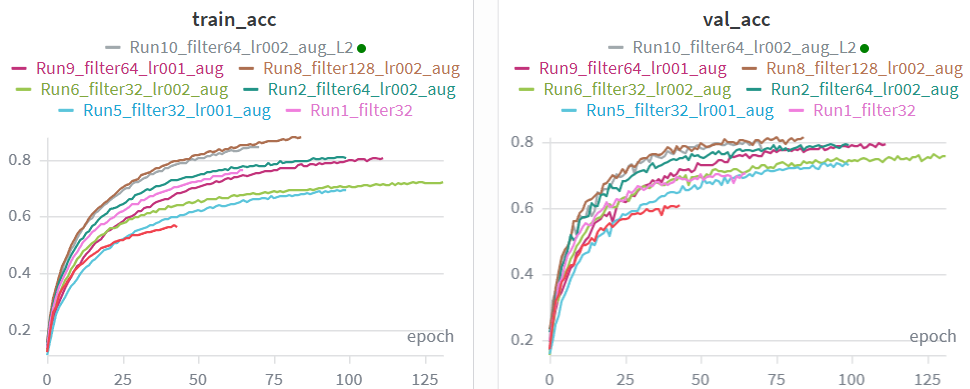

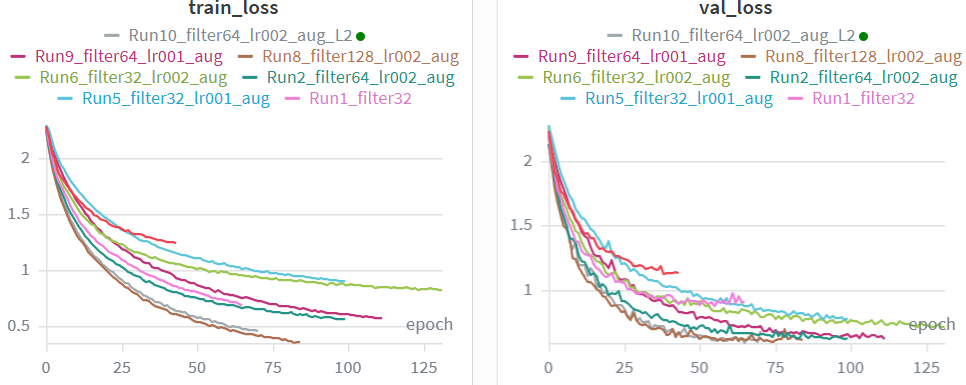

How good is your perception of colour?

We can clearly see the importance of hyperparameter tuning. With just a few experiments we were able to find models that outperform our best one in **Red** vastly. 
Parameters that we experimented with were learningrate, the amount of filters and regularizations. We did this by selectivly changing one parameter at a time and building on the better model.

Our Steps:
- We increased the amount of filter from our **Red Model** from 16 to 32, with a learningrate of 0.02 and no ata augmentation (**Pink Model**)
- We added data augmentation to our **Pink Model**, which gave us the **light Green Model** with better validation loss and a general better fit.
- We testes a learning rate of 0.01 instead of the 0.02 (**light Blue Model**) and saw no improvements over the previous Model
- We increased the amount of filters from 32 to 64 in our **Turquoise Model** and saw rise in performance and an overall good fit.
- We tried another increase in filter to 128 with our **Brown Model** but saw no significant validation loss improvement, and the start of overfitting.

**Decision**:
We decided to continue our work with the **Turquoise Model** since the no other Model was significantly better and it is overall a good fit.

## e) Testing different optimization algorithms

SGD with Momentum already has been implemented, which is why we now experiment with Adam and RMSProp.
For each experiment we just change one of the pairvalues in the optimizers.
For this we use our *best Model* from the previous tuning.

###

In [ ]:
run_configs = [
    {"name": "filter64_aug", "filters": 64, "dropout_conv": 0.1, "dropout_fc": 0.3, "augmented": True},
]

optimizer_configs = {
    "adam": [
        {"lr": 1e-3, "weight_decay": 1e-4, "betas": (0.9, 0.999)},  
        {"lr": 1e-3, "weight_decay": 1e-3, "betas": (0.9, 0.999)},   
        {"lr": 1e-3, "weight_decay": 1e-5, "betas": (0.9, 0.999)},  
 
    ],

    "rmsprop": [
        {"lr": 1e-3, "alpha": 0.99, "momentum": 0.0}, 
        {"lr": 1e-3, "alpha": 0.95, "momentum": 0.0},  
        {"lr": 1e-3, "alpha": 0.90, "momentum": 0.0}, 
 
    ],
}

for cfg in run_configs:
    train_data_used = train_data_augmented if cfg.get("augmented") else train_data

    for opt_name, opt_param_list in optimizer_configs.items():
        for opt_params in opt_param_list:
            
            param_str = "_".join(f"{k}{'_'.join(map(str, v)) if isinstance(v, tuple) else v}" for k, v in opt_params.items())
            run_name = f"{cfg['name']}_{opt_name}_{param_str}"

            wandb.init(
                project="PW01",
                name=run_name,
                config={
                    **cfg,
                    **opt_params,
                    "optimizer":    opt_name,
                    "batch_size":   64,
                    "epochs":       200,
                    "min_delta":    0.0,
                    "patience":     10,
                    "units":        128,
                }
            )

            config = wandb.config

            model = deepModel_drop(
                units=config["units"],
                filter=config["filters"],
                dropout_conv=config["dropout_conv"],
                dropout_fc=config["dropout_fc"]
            )

            if opt_name == "adam":
                optimizer = torch.optim.Adam(
                    params=model.parameters(),
                    lr=config["lr"],
                    weight_decay=config["weight_decay"],
                    betas=config["betas"]
                )
            elif opt_name == "rmsprop":
                optimizer = torch.optim.RMSprop(
                    params=model.parameters(),
                    lr=config["lr"],
                    alpha=config["alpha"],
                    momentum=config["momentum"]
                )

            train_eval(model, optimizer, config["epochs"], config["batch_size"],
                       train_data_used, val_data, device,
                       patience=config["patience"],
                       log_wandb=True,
                       min_delta=config["min_delta"])

            wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pascal/.netrc.
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.245787, 0.178083, 2.090380, 0.260333
Epoch 1: 2.024230, 0.275542, 1.864579, 0.333333
Epoch 2: 1.852091, 0.339875, 1.723057, 0.394833
Epoch 3: 1.730382, 0.386667, 1.568602, 0.468667
Epoch 4: 1.637405, 0.422333, 1.484231, 0.492500
Epoch 5: 1.573678, 0.445000, 1.380978, 0.522667
Epoch 6: 1.520371, 0.469667, 1.380290, 0.527500
Epoch 7: 1.460797, 0.488750, 1.314402, 0.544167
Epoch 8: 1.419465, 0.504292, 1.287380, 0.546167
Epoch 9: 1.383969, 0.514833, 1.203691, 0.592000
Epoch 10: 1.345879, 0.530750, 1.211850, 0.588833
Epoch 11: 1.313068, 0.546625, 1.156833, 0.609000
Epoch 12: 1.286692, 0.555292, 1.120177, 0.611833
Epoch 13: 1.257129, 0.563500, 1.095613, 0.631500
Epoch 14: 1.237784, 0.569083, 1.064836, 0.631167
Epoch 15: 1.221514, 0.578125, 1.097448, 0.620833
Epoch 16: 1.200073, 0.585750, 1.083811, 0.631833
Epoch 17: 1.166824, 0.600125, 1.028302, 0.645500
Epoch 18: 1.156863, 0.599333, 1.051462, 0.645500
Epoch 19: 1.131223, 0.614833, 0.998962, 0.656333
Epoch 20: 1.122027, 0.614083, 

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▅▅▆▇▇▇▇▇▇▇▇▇▇▇█▇█▇███████████████████
val_loss,█▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,139
train_acc,0.796
train_loss,0.60639
val_acc,0.78183
val_loss,0.66116


Epoch 0: 2.179503, 0.202292, 1.964208, 0.314167
Epoch 1: 1.915748, 0.321292, 1.828752, 0.331667
Epoch 2: 1.768165, 0.374417, 1.737714, 0.385500
Epoch 3: 1.660219, 0.417250, 1.533276, 0.476833
Epoch 4: 1.578446, 0.449625, 1.384316, 0.526833
Epoch 5: 1.510412, 0.471250, 1.328948, 0.544833
Epoch 6: 1.449316, 0.494375, 1.283072, 0.562000
Epoch 7: 1.408319, 0.513000, 1.258399, 0.565333
Epoch 8: 1.365045, 0.527917, 1.177307, 0.589833
Epoch 9: 1.320186, 0.543417, 1.155074, 0.601833
Epoch 10: 1.289410, 0.555333, 1.114509, 0.609833
Epoch 11: 1.253178, 0.566792, 1.113094, 0.625333
Epoch 12: 1.216679, 0.579667, 1.071919, 0.638333
Epoch 13: 1.195037, 0.588417, 1.026248, 0.635000
Epoch 14: 1.167217, 0.595875, 1.026947, 0.647000
Epoch 15: 1.141633, 0.607417, 1.076702, 0.631000
Epoch 16: 1.124466, 0.614792, 0.988634, 0.666333
Epoch 17: 1.100315, 0.627750, 0.947667, 0.672167
Epoch 18: 1.086543, 0.632417, 0.983657, 0.663333
Epoch 19: 1.070214, 0.630208, 0.948317, 0.673833
Epoch 20: 1.043766, 0.644000, 

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_acc,▁▂▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val_loss,█▇▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,86
train_acc,0.78263
train_loss,0.65191
val_acc,0.78567
val_loss,0.67441


Epoch 0: 2.186318, 0.197375, 1.981190, 0.306000
Epoch 1: 1.956564, 0.306083, 1.788799, 0.368833
Epoch 2: 1.801613, 0.363833, 1.663343, 0.409333
Epoch 3: 1.680341, 0.413458, 1.519210, 0.475333
Epoch 4: 1.588070, 0.443750, 1.469697, 0.480667
Epoch 5: 1.517365, 0.469792, 1.343309, 0.537000
Epoch 6: 1.454439, 0.491542, 1.344494, 0.539500
Epoch 7: 1.413221, 0.511208, 1.234081, 0.575833
Epoch 8: 1.355120, 0.531667, 1.241869, 0.568833
Epoch 9: 1.314280, 0.545958, 1.173330, 0.593000
Epoch 10: 1.286299, 0.553125, 1.141595, 0.598000
Epoch 11: 1.252287, 0.569583, 1.151463, 0.605667
Epoch 12: 1.224433, 0.577750, 1.092627, 0.618000
Epoch 13: 1.203636, 0.582958, 1.058552, 0.634833
Epoch 14: 1.172224, 0.596375, 1.030968, 0.646833
Epoch 15: 1.154919, 0.606958, 1.049556, 0.636500
Epoch 16: 1.123020, 0.616833, 0.986427, 0.655333
Epoch 17: 1.108136, 0.622208, 0.978726, 0.663833
Epoch 18: 1.092630, 0.629708, 0.980711, 0.661333
Epoch 19: 1.070965, 0.636042, 0.927191, 0.682833
Epoch 20: 1.054969, 0.642500, 

epoch,▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▃▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇█████████████████████
train_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███▇██████████████
val_loss,█▇▆▅▅▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,74
train_acc,0.73
train_loss,0.83278
val_acc,0.74217
val_loss,0.77707


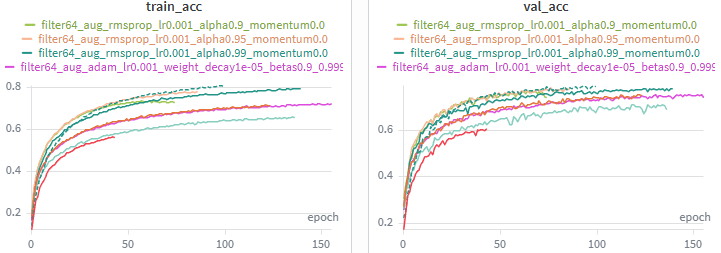

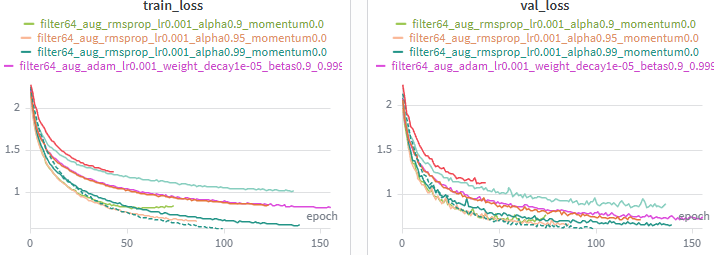

For our Optimizer experiment we tested Adam and RMSProp, since SGD with momentum already was inplemented with our current best Model.
For Adam and RMSProp we again only changed one value at a time, because of GPU limits we only tested 3 different **weight decays** for Adam and 3 different **alphas** for Adam.
In our case we got the best performance by using SGD with momentum = 0.9 and lr = 0.02


# Final Model

## load Dataset with full size

In [5]:
transform_full = transforms.Compose([
    transforms.ToTensor()
])

train_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_full
)

In [6]:
loader = DataLoader(train_data_full, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)  
    mean += images.mean(dim=2).sum(dim=0)
    std += images.std(dim=2).sum(dim=0)
    total_samples += batch_size

mean /= total_samples
std /= total_samples
print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4966, 0.4792, 0.3941])
Std:  tensor([0.2191, 0.2158, 0.2195])


In [7]:
transform_full = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

transform_augmented_full = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_full
)

train_data_augmented_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_augmented_full
)

val_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/validate",
    transform=transform_full
)

In [8]:
print("Train samples:", len(train_data_full))
print("Val samples:", len(val_data_full))
print(train_data_full.classes)

Train samples: 24000
Val samples: 6000
['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


In [9]:
image, label = train_data_full[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


In [10]:
print("Min pixel value:", image.min())
print("Max pixel value:", image.max())

Min pixel value: tensor(-2.2667)
Max pixel value: tensor(2.7598)


/tmp/ipykernel_2197/243498538.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean_t = torch.tensor(mean).view(3, 1, 1)
/tmp/ipykernel_2197/243498538.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_t = torch.tensor(std).view(3, 1, 1)


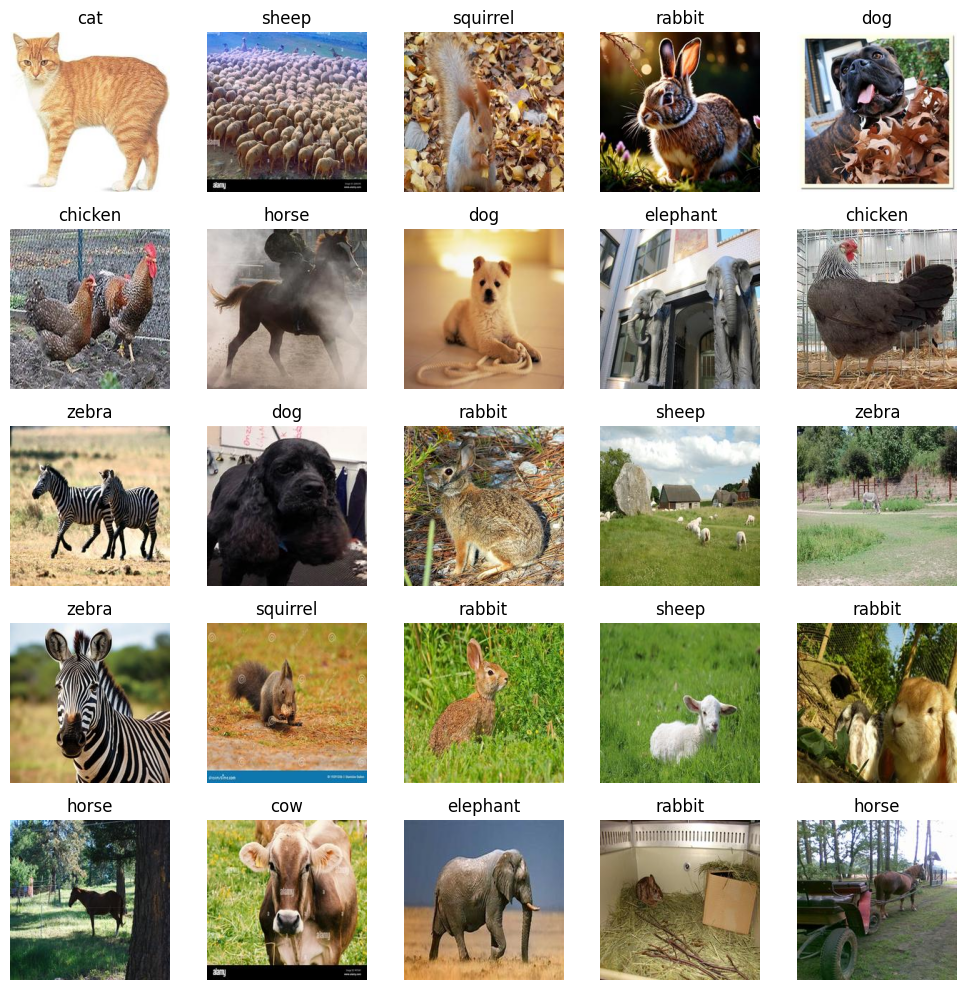

In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

loader = DataLoader(train_data_full, batch_size=25, shuffle=True)
images, labels = next(iter(loader))

# denormalize
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)
images_denorm = images * std_t + mean_t
images_denorm = images_denorm.clamp(0, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i in range(25):
    img = images_denorm[i].permute(1, 2, 0)

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(train_data_full.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
run_configs = [
    {"name": "Model_full",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data_full, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pascal/.netrc.
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.223731, 0.169042, 2.080594, 0.249333
Epoch 1: 2.040775, 0.259417, 1.976284, 0.293833
Epoch 2: 1.956047, 0.297208, 1.844035, 0.346667
Epoch 3: 1.882535, 0.324167, 1.780362, 0.369500
Epoch 4: 1.812607, 0.349250, 1.726698, 0.401333
Epoch 5: 1.759889, 0.371792, 1.670700, 0.404667
Epoch 6: 1.706571, 0.393292, 1.574229, 0.440667
Epoch 7: 1.661959, 0.408625, 1.585884, 0.445167
Epoch 8: 1.609402, 0.427208, 1.459407, 0.494000
Epoch 9: 1.560799, 0.441958, 1.496244, 0.487667
Epoch 10: 1.511509, 0.458750, 1.414700, 0.504167
Epoch 11: 1.478382, 0.474250, 1.333181, 0.533833
Epoch 12: 1.455049, 0.486583, 1.303868, 0.558333
Epoch 13: 1.411472, 0.499292, 1.248698, 0.560500
Epoch 14: 1.392208, 0.508250, 1.223135, 0.575833
Epoch 15: 1.357798, 0.519583, 1.277102, 0.553500
Epoch 16: 1.345436, 0.523625, 1.213198, 0.576833
Epoch 17: 1.310997, 0.536500, 1.178863, 0.592333
Epoch 18: 1.299283, 0.544167, 1.145266, 0.593333
Epoch 19: 1.281528, 0.549875, 1.133090, 0.609667
Epoch 20: 1.269201, 0.554708, 

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x741517f23920>> (for post_run_cell), with arguments args (<ExecutionResult object at 7415241a4830, execution_count=20 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7415242778f0, raw_cell="run_configs = [
    {"name": "Model_full",        .." transformed_cell="run_configs = [
    {"name": "Model_full",        .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/pascal/Deeplearning/PW01/MPW01.ipynb#Y121sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

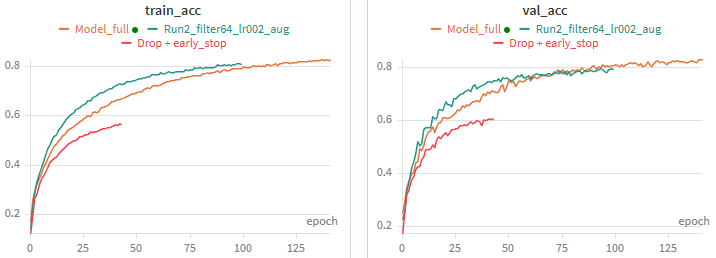

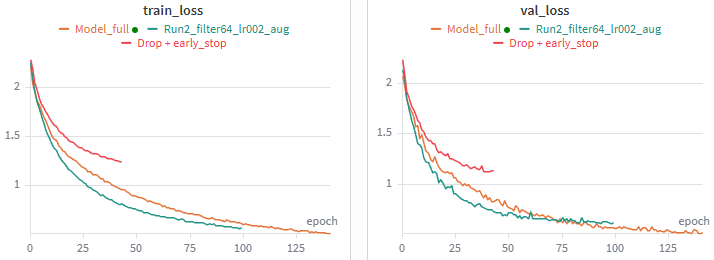

With the same model and the exact same parameters, we observed only a slight improvement when using the full-resolution data. I had expected the improvement to be larger, since even I sometimes struggled to recognise what was shown in the 64×64 images. Therefore, when switching to 224×224, I intuitively assumed that the model performance would increase more significantly. However, the validation accuracy only reached 83%, which is about 4% higher than with 64×64 images. One possible explanation is that, as the input resolution increases, the model may require additional layers to effectively capture and aggregate the more complex spatial information present in higher-resolution images.

## Maybe an Additional Layer helps

In [24]:
class deepModel2_drop(torch.nn.Module):

    def __init__(self, units=128, filter=16, n_classes=10, dropout_conv=0.2, dropout_fc=0.5):
        super(deepModel2_drop, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 4
            torch.nn.Conv2d(filter*4, filter*8, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Flatten and Dense
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*8, units),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_fc),

            # Output
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)

In [17]:
model = deepModel2_drop().to(device)
from torchsummary import summary
summary(model, (3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
              ReLU-2         [-1, 16, 224, 224]               0
         MaxPool2d-3         [-1, 16, 112, 112]               0
         Dropout2d-4         [-1, 16, 112, 112]               0
            Conv2d-5         [-1, 32, 112, 112]           4,640
              ReLU-6         [-1, 32, 112, 112]               0
         MaxPool2d-7           [-1, 32, 56, 56]               0
         Dropout2d-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          18,496
             ReLU-10           [-1, 64, 56, 56]               0
        MaxPool2d-11           [-1, 64, 28, 28]               0
        Dropout2d-12           [-1, 64, 28, 28]               0
           Conv2d-13          [-1, 128, 28, 28]          73,856
             ReLU-14          [-1, 128,

In [ ]:
run_configs = [
    {"name": "Model_full_4L_s",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel2_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data_full, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

Epoch 0: 2.228467, 0.155875, 2.118391, 0.206833
Epoch 1: 2.065287, 0.244458, 2.009623, 0.260333
Epoch 2: 1.971869, 0.290333, 1.859882, 0.331500
Epoch 3: 1.868486, 0.330250, 1.742774, 0.385333
Epoch 4: 1.782544, 0.359542, 1.670559, 0.395667
Epoch 5: 1.703067, 0.386875, 1.560788, 0.442500
Epoch 6: 1.638482, 0.412542, 1.525427, 0.439333
Epoch 7: 1.570142, 0.433208, 1.450062, 0.483000
Epoch 8: 1.512178, 0.456333, 1.396125, 0.496500
Epoch 9: 1.466408, 0.479958, 1.326172, 0.541500
Epoch 10: 1.407621, 0.499167, 1.242226, 0.561833
Epoch 11: 1.354045, 0.520583, 1.239158, 0.559833
Epoch 12: 1.313700, 0.535208, 1.170192, 0.588333
Epoch 13: 1.277543, 0.544667, 1.152708, 0.596167
Epoch 14: 1.235327, 0.564500, 1.118415, 0.604500
Epoch 15: 1.219097, 0.569333, 1.064792, 0.627167
Epoch 16: 1.164269, 0.593792, 1.014934, 0.649500
Epoch 17: 1.136427, 0.601750, 1.008917, 0.652333
Epoch 18: 1.109474, 0.615500, 0.964680, 0.665833
Epoch 19: 1.072385, 0.627958, 0.908056, 0.688667
Epoch 20: 1.044683, 0.636667, 

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7df681555ac0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7df6b07ac980, execution_count=25 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7df6b07acf80, raw_cell="run_configs = [
    {"name": "Model_full_4L_s",   .." transformed_cell="run_configs = [
    {"name": "Model_full_4L_s",   .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/pascal/Deeplearning/PW01/MPW01.ipynb#Y130sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

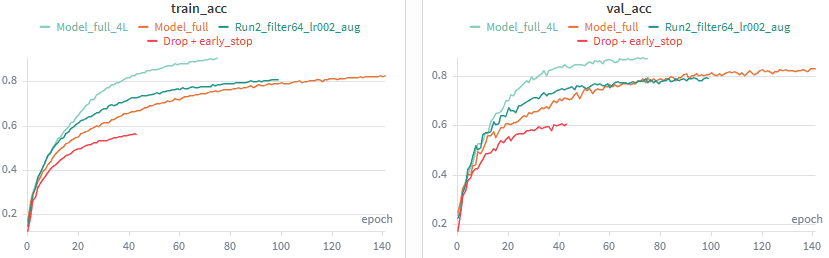

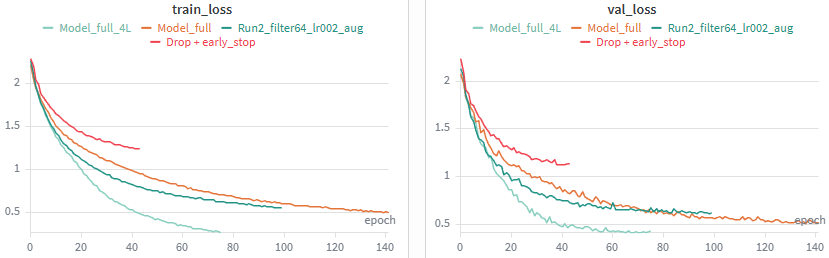


With an additional Layer we were able to achive a Validation accuracy of 87%, a slight improvement of 4% compared to our Model with just 4 Layers.